In [1]:
%autosave 60
%cd ..
%reload_ext autoreload
%autoreload 2

Autosaving every 60 seconds
/Users/yulia/Library/CloudStorage/Dropbox/MTC/PY projects hw/_Math/14_EDA_Terrorism_ds


# Домашнее задание EDA | МТС Тета
-----
- Нужно провести EDA любого датасета на ваше усмотрение в специально подготовленном ipynb
- В этом ноутбуке будут блоки под разные типы графиков
- Нужно выбрать такой датасет, который позволит построить каждый из этих графиков корректно
- В ноутбуке так же будет дополнительное поле для графика на ваш выбор. В нем должен быть график, который не был построен ранее в ноутбуке (другой тип графика)
- Ноутбук должен отбегать в режиме run all, а так же сохранять все изображения шаблонным образом, как заложено в ноутбуке
- Для каждого графика должны быть написаны выводы
- __Вместе с ноутбуком нужно сдать сохраненные изображения (проверьте корректность их сохранения перед отправкой ДЗ)__
- изображения должны быть в формате png или jpeg. Не сохраняйте изображения в html (так делает plotly)
____
**Критерии оценки**
- Вы построили все основные графики без критических ошибок – 8 баллов
- Вы выполнили пункт 1, а так же построили дополнительный график - 10 баллов
- Доп. баллы выставляются за победу в tinder игре – подробности будут позже. Но чтобы в ней победить, ваш график должен оказаться самым красивым. 
- Доп. Баллы получат топ 10 человек итогового рейтинга. 
---
- Максимум 10 баллов (и +5 дополнительных)
- 1-4 балла: незачет
- 5-6 баллов: 3, незачет
- 7-8 баллов: 4, зачет
- 9-10 баллов: 5, зачет

## подготовка

In [2]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sb
from matplotlib.ticker import PercentFormatter

from src.plot_utils import *
from src.translation_utils import translate_attack_types


plt.style.use("styles/plot_style.mplstyle")

In [3]:
# подставьте ваше имя и фамилию в эту переменную как в примере, (например Максим_Шаланкин)
image_name_prefix = 'Юлия_Никитина'

# можно поменять, а можно оставить - сюда будут сохраняться изображения
path_to_save_images = 'images'

In [4]:
os.makedirs(path_to_save_images, exist_ok=True)

### Global Terrorism datased (1980-2017)

In [5]:
# обработка сырого датасета сделана в ноутбуке 01_data_preparation.ipynb
# отфильтрованы и обработаны колонки, нужные для построения графиков EDA.
# тут загрузка чистого датасета:

df = pd.read_csv('data/terrorism_clean.csv', encoding='latin1', low_memory=False)


In [6]:
# типы терактов: перевод на русский

df = translate_attack_types(df)

## (1) line plot

**Динамика видов атак по годам**

In [7]:
# количество терактов по годам
attack_counts_by_year = (
    df[df['attack_type'].isin(
        df['attack_type'].value_counts().head(5).index)]
    .groupby(['year','attack_type'])
    .size().reset_index(name='count'))


In [8]:
# количество пострадавших по годам
victim_total_by_year = (df.groupby('year')['victims'].sum().reset_index())

/Users/yulia/Library/CloudStorage/Dropbox/MTC/PY projects hw/_Math/14_EDA_Terrorism_ds/src/plot_utils.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend(


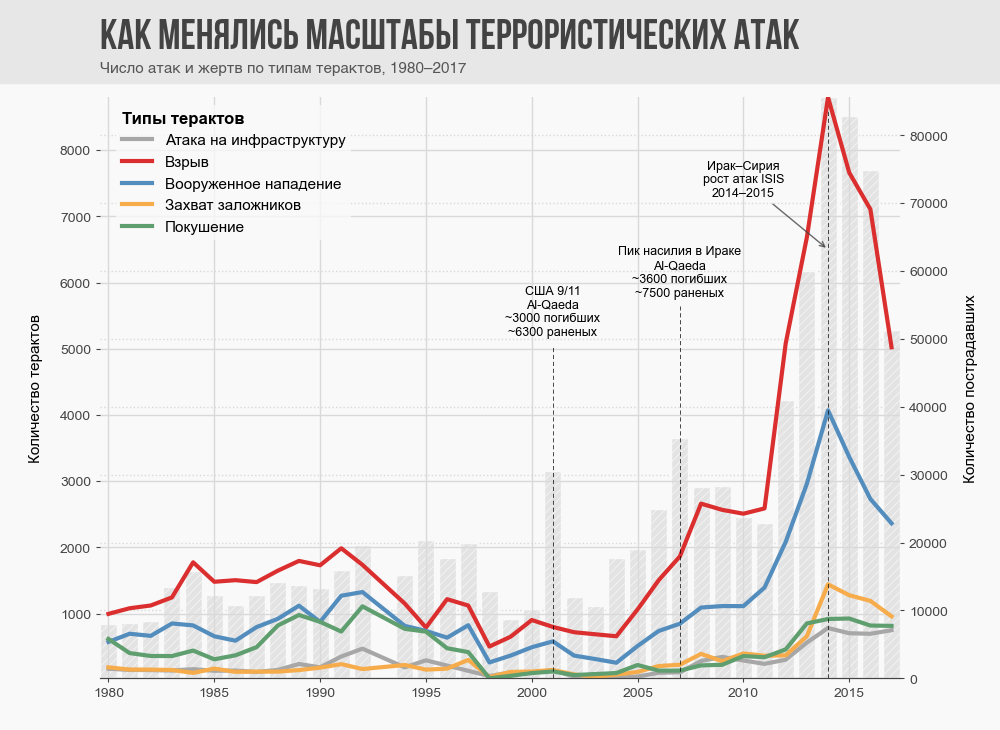

In [ ]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.set_axisbelow(True)
ax2.set_axisbelow(True)

ax1.set_zorder(2)
ax2.set_zorder(1)

ax1.patch.set_visible(False)

# barplot: количество пострадавших по годам
ax2.bar(
    victim_total_by_year['year'],
    victim_total_by_year['victims'],
    color="#E3E3E3", alpha=1, width=0.8,
    hatch="////", edgecolor="#f9f9f9",
    label="∑ пострадавших в год")

# lineplot: динамика типов терактов
sb.lineplot(
    data=attack_counts_by_year,
    x='year', y='count',
    hue='attack_type', 
    palette=ATTACK_COLORS,
    linewidth=3, ax=ax1, alpha=1,)

# события
ax1.axvline(2001, ymax=0.57, color="black", linestyle="--", linewidth=0.5)
ax1.axvline(2007, ymax=0.64, color="black", linestyle="--", linewidth=0.5)
ax1.axvline(2014, ymax=0.98, color="black", linestyle="--", linewidth=0.5)

ax1.text(2001, 5200, "США 9/11\nAl-Qaeda\n~3000 погибших\n~6300 раненых", ha="center", fontsize=9)
ax1.text(2007, 5800, "Пик насилия в Ираке\nAl-Qaeda\n~3600 погибших\n~7500 раненых", ha="center", fontsize=9)

ax1.annotate(
    "Ирак–Сирия\nрост атак ISIS\n2014–2015",
    xy=(2014, 6500),  
    xytext=(2010, 7300), 
    fontsize=9,
    ha="center",
    arrowprops=dict(arrowstyle="->", lw=1, color="#444444", alpha=0.8)
)

ax1.grid(True, linestyle="-")
ax2.grid(True, linestyle=":")

ax1.set_xlabel(" ")
ax1.set_ylabel("Количество терактов")
ax2.set_ylabel("Количество пострадавших")

# патч для легенды барплота
# from matplotlib.patches import Patch

# handles, labels = ax1.get_legend_handles_labels()

# victims_patch = Patch(
#     facecolor="#DDDDDD",
#     edgecolor="#f9f9f9",
#     hatch="////",
#     label="∑ пострадавших в год"
# )

# handles.append(victims_patch)

# ---------------------------------

style_legend(ax1, 'Типы терактов', alpha=0.8, loc='tl', shift_x=0.01)
style_legend(ax2, 'S ', alpha=0.8, loc='cl', shift_x=0.01)

style_title(ax1, "Как менялись масштабы террористических атак", 
                 "Число атак и жертв по типам терактов, 1980–2017")


fig.savefig(os.path.join(path_to_save_images, f'{image_name_prefix}_image_1.png'),
                dpi=300, bbox_inches="tight")
plt.show()

#### **выводы** (1):
С 1980-х до начала 2000-х террористические атаки происходили в основном в рамках региональных конфликтов, общее число атак и жертв менялось умеренно.

В начале XXI века ситуация изменилась. В 2001 году глобальную статистику по числу жертв резко поднял один очень крупный теракт – атака на Башни-близнецы в США (9/11). Общее число пострадавших составило более 9000 человек (около 3000 погибших и более 6000 раненых).

После 2012 года начинается устойчивый рост террористической активности. На графике видно резкое увеличение числа атак и пострадавших, связанное с активностью радикальных группировок на Ближнем Востоке, прежде всего в Ираке и Сирии (ISIS).

Рост происходит главным образом за счет увеличения числа взрывов и вооруженных нападений. В этот же период заметно возрастает количество случаев захвата заложников. После 2015 года показатели постепенно снижаются.

## (2) (bar plot или stacked bar plot)

**Типы атак по террористическим организациям**

In [10]:
# уберем неизвестные группировки и типы атак
df_clean = df[
    (df['group_name'] != 'Unknown') &
    (df['attack_type'] != 'Unknown')].copy()

# топ группировок
top_org = (df_clean['group_name'].value_counts().head(10).index)

# топ типов атак
top_attacks = (df_clean['attack_type'].value_counts().head(5).index)

In [11]:
top_org

Index(['Other', 'Taliban', 'Islamic State', 'Shining Path',
       'Communist / Maoist', 'FMLN', 'Al-Shabaab', 'NPA', 'FARC',
       'Boko Haram'],
      dtype='object', name='group_name')

In [12]:
# создаем колонку, где редкие типы атак объединяются в Other
df_clean['attack_type_grouped'] = df_clean['attack_type']

df_clean.loc[
    ~df_clean['attack_type'].isin(top_attacks),
    'attack_type_grouped'
] = 'Другое'

In [13]:
# сборка таблицы
table = (df_clean[df_clean['group_name'].isin(top_org)]
        .groupby(['group_name','attack_type_grouped'])
        .size().unstack(fill_value=0))

# сортировка
table = table[table.sum().sort_values(ascending=False).index]
table = table.loc[table.sum(axis=1).sort_values(ascending=False).index]

# проценты
table_pct = table.div(table.sum(axis=1), axis=0)

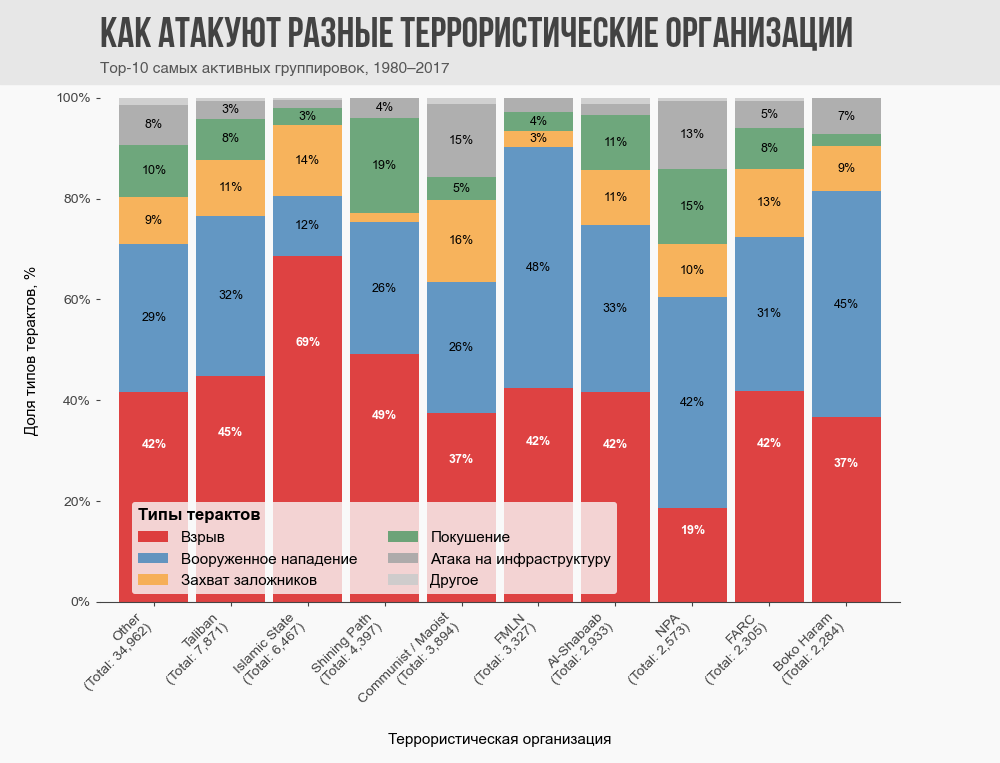

In [14]:
fig, ax = plt.subplots()
fig.subplots_adjust(top=0.82, bottom=0.1)

# stacked bar plot
table_pct.plot(
    kind='bar', stacked=True,
    color=attack_palette(table_pct.columns),
    width=0.9, alpha=0.9, ax=ax)

# подпишем проценты 
for container, attack_type in zip(ax.containers, table_pct.columns):

    for bar, value in zip(container, container.datavalues):
        if value < 0.03:
            continue

        x = bar.get_x() + bar.get_width()/2
        y = bar.get_y() + bar.get_height()/2

        if attack_type == "Взрыв":
            y = bar.get_y() + bar.get_height()*0.75
            text_color = "white"
            weight = "bold"
        else:
            text_color = "black"
            weight = "normal"

        ax.text(
            x, y,
            f"{value:.0%}",
            ha="center",
            va="center",
            fontsize=9,
            color=text_color,
            fontweight=weight)

ax.yaxis.set_major_formatter(PercentFormatter(1))

# суммарное количество атак
totals = (df_clean[df_clean['group_name'].isin(table_pct.index)]
    .groupby('group_name').size())

# добавим в подписи x
new_labels = [f"{name}\n(Total: {int(totals.loc[name]):,})"
              for name in table_pct.index]

ax.set_xticklabels(new_labels, rotation=45, ha="right")

ax.set_xlabel("Террористическая организация\n")
ax.set_ylabel("Доля типов терактов, %")

style_legend(ax, 'Типы терактов', alpha=0.8, ncol=2, loc='bl', shift_x=0.03)
style_title(ax,
    "Как атакуют разные террористические организации",
    "Top-10 самых активных группировок, 1980–2017")


fig.savefig(os.path.join(path_to_save_images, f'{image_name_prefix}_image_2.png'),
                dpi=300, bbox_inches="tight")
plt.show()

#### **выводы** (2):
Взрывы – самый популярный тип атак у 6 из 9 наиболее активных террористических организаций. У Islamic State (Ирак–Сирия, джихадистская) доля взрывов достигает 69% всех атак. На втором месте Shining Path (Перу, маоистские повстанцы) – 49%, на третьем Taliban (Афганистан–Пакистан, исламисты) – около 45%.

При этом FLMN (Сальвадор, леворадикальные партизаны), Boko Haram (Нигерия, джихадистская организация) и NPA (Филлипины, партизанская огранизация) чаще используют вооруженные нападения, чем другие типы атак. Суммарно на взрывы и вооруженные нападения приходится больше половины всех терактов.

Талибан остается лидером по общему числу терактов за период 1980–2017 годов – всего 7,871 атак.

В категорию Other попали около 2900 менее известных группировок по всему миру. Вместе они совершили 34_962 терактов: больше, чем любая отдельная организация.

##  (3) (hist plot или pair plot или kde plot)

**Распределения типов атак по количеству жертв**

In [15]:
# выбранные типы атак
selected_attack = ['Взрыв', 'Вооруженное нападение', 'Покушение', 'Захват заложников']

# сумма погибших по годам
killed_year = (
    df[df['attack_type'].isin(selected_attack)]
    .groupby(['year','attack_type'])['victims']
    .sum().reset_index())

# обрезаем хвост распределения
p95 = killed_year['victims'].quantile(0.95)
data_plot = killed_year[killed_year['victims'] <= p95]

In [16]:
# вычисляем mean и median
means = killed_year.groupby('attack_type')['victims'].mean().astype(int)
medians = killed_year.groupby('attack_type')['victims'].median().astype(int)
medians

attack_type
Взрыв                    7432
Вооруженное нападение    4702
Захват заложников         309
Покушение                 935
Name: victims, dtype: int64

In [17]:
mins = killed_year.groupby('attack_type')['victims'].min().astype(int)
mins

attack_type
Взрыв                    3468
Вооруженное нападение    1970
Захват заложников          37
Покушение                 104
Name: victims, dtype: int64

In [18]:
idx = (
    df[df['attack_type'].isin(selected_attack)]
    .groupby('attack_type')['victims']
    .idxmax()
)
largest_attacks = df.loc[idx]
events = largest_attacks[['attack_type', 'group_name', 'group_details', 'year', 
    'month', 'day', 'country', 'killed', 'victims', 'summary']].copy()

events['victims'] = events['victims'].astype(int)
events['killed'] = events['killed'].astype(int)
events = events.sort_values('year')

attack_short = {
    "Вооруженное нападение": "Нападение",
    "Покушение": "Покушение",
    "Взрыв": "Взрыв",
    "Захват заложников": "Заложники"
}

events["attack_short"] = events["attack_type"].map(attack_short)

events

,attack_type,group_name,group_details,year,month,day,country,killed,victims,summary,attack_short
46018,Вооруженное нападение,Other,Hutu extremists,1994,4,13,Rwanda,1180,1180,NaN,Нападение
47690,Покушение,LTTE,Liberation Tigers of Tamil Eelam (LTTE),1994,10,24,Sri Lanka,54,354,NaN,Покушение
58155,Взрыв,Al-Qaida,Al-Qaida,1998,8,7,Kenya,224,4224,08/07/1998: Suicide attackers detonated a vehi...,Взрыв
123602,Захват заложников,Islamic State,Islamic State of Iraq and the Levant (ISIL),2014,6,12,Iraq,1570,1570,06/12/2014: Assailants abducted approximately ...,Заложники


In [19]:
# вооруженное нападение
events.loc[46018, 'group_name'] = f'Hutu'
events.loc[46018, 'summary'] = f'Массовый\nрасстрел тутси\nэкстремистами\nхуту'

# взрыв
events.loc[47690, 'summary'] = f'Покушение на\nкандидата\nв президенты\nна митинге\n(убиты: 54\nранены: 300)'

# захват заложников
events.loc[123602, 'group_name'] = f'ISIL'
events.loc[123602, 'summary'] = f'Захват и казнь\nшиитских\nсолдат в\nCamp Speicher\n(все убиты)'

# Покушение
events.loc[58155, 'summary'] = f'Взрыв у\nпосольства\nСША\n(убиты: 224\nранены: 4000)'

events


,attack_type,group_name,group_details,year,month,day,country,killed,victims,summary,attack_short
46018,Вооруженное нападение,Hutu,Hutu extremists,1994,4,13,Rwanda,1180,1180,Массовый\nрасстрел тутси\nэкстремистами\nхуту,Нападение
47690,Покушение,LTTE,Liberation Tigers of Tamil Eelam (LTTE),1994,10,24,Sri Lanka,54,354,Покушение на\nкандидата\nв президенты\nна мити...,Покушение
58155,Взрыв,Al-Qaida,Al-Qaida,1998,8,7,Kenya,224,4224,Взрыв у\nпосольства\nСША\n(убиты: 224\nранены:...,Взрыв
123602,Захват заложников,ISIL,Islamic State of Iraq and the Levant (ISIL),2014,6,12,Iraq,1570,1570,Захват и казнь\nшиитских\nсолдат в\nCamp Speic...,Заложники


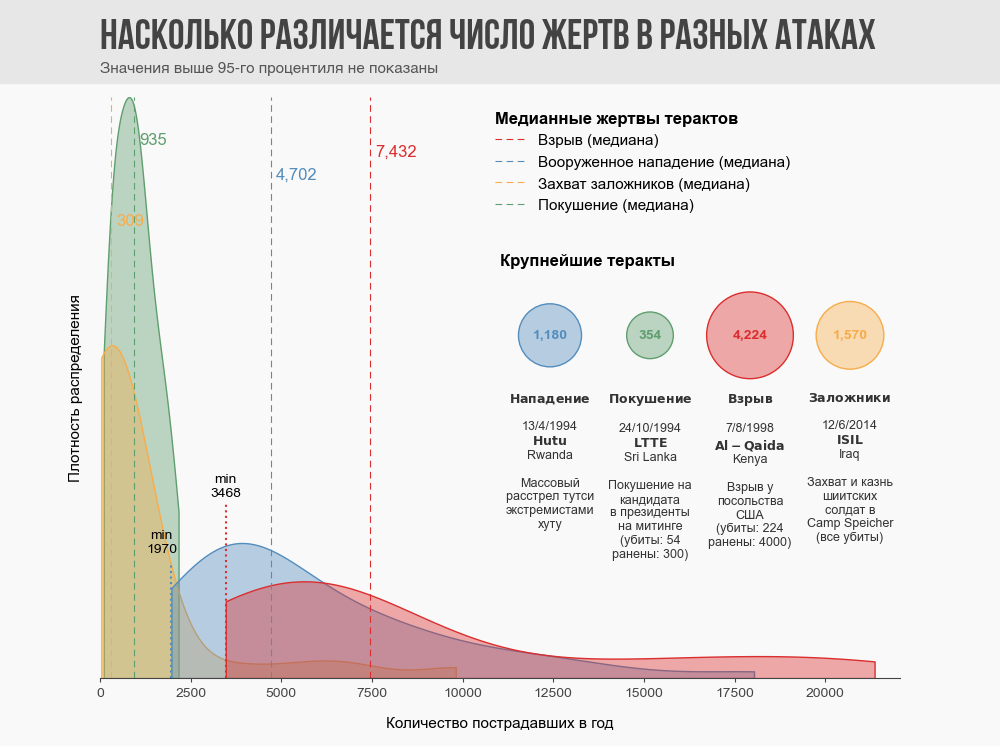

In [20]:
import matplotlib.colors as mcolors

palette = ATTACK_COLORS
colors = events['attack_type'].map(ATTACK_COLORS)

fig, ax = plt.subplots()

# KDE
ax = sb.kdeplot(data=data_plot, x='victims',
    hue='attack_type', palette=palette, fill=True,
    common_norm=False, alpha=0.4, cut=0)

# слишком длинный хвост, берем 95 процентиль
plt.xlim(0, p95)

# медианы: смещение
y_offset = {
    "Взрыв": 0.92,
    "Вооруженное нападение": 0.88,
    "Покушение": 0.94,
    "Захват заложников": 0.80}

# медианы: линии
for attack, victims in medians.items():
    ax.axvline(victims, 
        color=palette[attack],
        ls='--', lw=0.8,
        label=f"{attack} (медиана)")

    # медианы: значения
    ax.text(
        victims+150,
        ax.get_ylim()[1] * y_offset[attack],
        f"{victims:,}",
        color=palette[attack],
        ha="left", va="top",
        fontsize=12)

# минимумы: линии
ax.axvline(mins['Взрыв'], ymax=0.3, color=palette['Взрыв'], ls=":", lw=1.5)
ax.axvline(mins['Вооруженное нападение'], ymax=0.2, color=palette['Вооруженное нападение'], ls=":", lw=1.5)

# минимумы: значения
ax.text(mins['Взрыв'], 0.000180, f"min\n{mins['Взрыв']}", 
    color='black', ha="center", fontsize=10)
ax.text(mins['Вооруженное нападение']-270, 0.000125, f"min\n{mins['Вооруженное нападение']}", 
    color='black', ha="center", fontsize=10)

ax.set_yticks([])

plt.xlabel("Количество пострадавших в год\n")
plt.ylabel("Плотность распределения")

style_legend(ax, 'Медианные жертвы терактов', loc='tr', shift_x=-0.12)
style_title(ax,
    "Насколько различается число жертв в разных атаках",
    "Значения выше 95-го процентиля не показаны")


# --- inset график: самые массовые атаки -------------------

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

ax_inset = inset_axes(ax, width="50%", height="17%", loc="center right", borderpad=0,
                      bbox_to_anchor=(0, 0.09, 1, 1), bbox_transform=ax.transAxes,)

sizes = np.sqrt(events['victims']) * 60

# кружочки: scatter
ax_inset.scatter(
    range(len(events)), [0]*len(events), s=sizes,
    facecolors=[mcolors.to_rgba(c, alpha=0.4) for c in colors],
    edgecolors=colors, linewidth=1,
    label=' ')

# значения в кружочках 
for i, victims in enumerate(events['victims']):
    ax_inset.text(
        i, 0, f"{victims:,}",
        ha="center", va="center",
        fontsize=10, weight="bold",
        color=colors.iloc[i])

# комментарии к событиям
labels = [
    f"$\\bf{{{row['attack_short']}}}$\n\n"
    f"{row['day']}/{row['month']}/{row['year']}\n"
    f"$\\bf{{{row['group_name']}}}$\n"
    f"{row['country']}\n\n"
    f"{row['summary']}"
    for _, row in events.iterrows()
]

for i, txt in enumerate(labels):
    ax_inset.text(i, -0.45, txt, ha="center", va="top", fontsize=9, color='#333333')

for spine in ax_inset.spines.values():
    spine.set_visible(False)

ax_inset.set_xticks([])
ax_inset.set_yticks([])
ax_inset.set_xlim(-0.5, len(events)-0.5)
ax_inset.set_ylim(-0.4, 0.4)

ax_inset.set_title("Крупнейшие теракты", fontsize=12)


fig.savefig(os.path.join(path_to_save_images, f'{image_name_prefix}_image_3.png'),
                dpi=300, bbox_inches="tight")

plt.show()

#### **выводы** (3): 
- Взрывы оказываются самым смертоносным типом атак. 
Медианное число потерпевших от взрывов в год составляет около 7 432, а в отдельные годы потери достигают десятков тысяч. Даже минимальное годовое число жертв взрывов (погибшими и ранеными) за период 1980–2017 не опускалось ниже 3 468 в год.

- Вооруженные нападения занимают второе место по масштабам потерь. Их медианное значение составляет около 3 468 жертв в год, а минимальное около 1 970.

- Покушения и захваты заложников приводят к значительно меньшим потерям. Их медианные значения: примерно 935 и 309 жертв в год.

Наиболее крупные человеческие потери связаны со взрывами и вооруженными нападениями, а покушения и захваты заложников обычно имеют более ограниченные последствия.

##  (4) heatmap plot

**Смертность от разных типов атак по регионам**

In [21]:
# выберем top-5 типов атак по victims
top_attacks_list = (df.groupby('attack_type')['victims']
    .size().sort_values(ascending=False).head(5).index.tolist())

top_attacks_list

['Взрыв',
 'Вооруженное нападение',
 'Покушение',
 'Захват заложников',
 'Атака на инфраструктуру']

In [22]:
# таблица жертв по регионy
table = (df[df['attack_type'].isin(top_attacks_list)]
    .groupby(['region', 'attack_type'])['victims']
    .sum().unstack(fill_value=0))

# порядок типов атак
table = table.reindex(columns=top_attacks_list)

table = table.astype(int)
table

attack_type,Взрыв,Вооруженное нападение,Покушение,Захват заложников,Атака на инфраструктуру
region,,,,,
Australasia & Oceania,65,165,43,40,13
Central America & Caribbean,5109,28256,1679,339,190
Central Asia,1198,1388,190,28,10
East Asia,1506,1315,75,53,114
Eastern Europe,11936,3898,777,2007,96
Middle East & North Africa,266584,40718,9047,15778,995
North America,1930,2102,254,255,444
South America,14961,20339,4681,1252,377
South Asia,139284,63608,11848,7223,1693


In [23]:
# примерное население 
region_population = {
    "South Asia": 1_850_000_000,
    "East Asia": 1_640_000_000,
    "Southeast Asia": 650_000_000,
    "Sub-Saharan Africa": 1_030_000_000,
    "Middle East & North Africa": 440_000_000,
    "Western Europe": 196_000_000,
    "Eastern Europe": 292_000_000,
    "Central America & Caribbean": 180_000_000,
    "South America": 430_000_000,
    "North America": 365_000_000,
    "Central Asia": 72_000_000,
    "Australasia & Oceania": 41_000_000
}

In [24]:
# для линейки ИНДЕКС ТЕРРОРИЗМА

# вычисляем общую интенсивность терроризма:
# сумма жертв по региону по всем атакам
victims_region = (df.groupby("region")["victims"].sum().reset_index())

# население региона из словаря
victims_region["population"] = victims_region["region"].map(region_population)

# доля жертв в каждом регионе от общего числа жертв
victims_region["victim_share"] = victims_region["victims"] / victims_region["victims"].sum()

# доля населения региона от общего числа по миру
victims_region["population_share"] = victims_region["population"] / sum(region_population.values())

# индекс терроризма (отношение доли жертв к доли мирового населения)
victims_region["terrorism_intensity"] = (
    victims_region["victim_share"] /
    victims_region["population_share"])

# сортировка таблицы для хитмап
victims_region = victims_region.sort_values("terrorism_intensity", ascending=False)
region_order = victims_region["region"]
table_sorted = table.loc[region_order]

# таблица индекса терроризма
heat_index = victims_region.set_index("region")[["terrorism_intensity"]]

heat_index

,terrorism_intensity
region,
Middle East & North Africa,6.176878
Central America & Caribbean,1.581799
South Asia,1.023158
Sub-Saharan Africa,0.987599
South America,0.808959
Western Europe,0.777953
North America,0.545579
Eastern Europe,0.518819
Southeast Asia,0.485811


In [25]:
# суммарное количество жертв по региону
region_totals = table_sorted.sum(axis=1)

# проценты для каждого типа атак от всех жертв в регионе
table_pct = table_sorted.div(table_sorted.sum(axis=1), axis=0) * 100

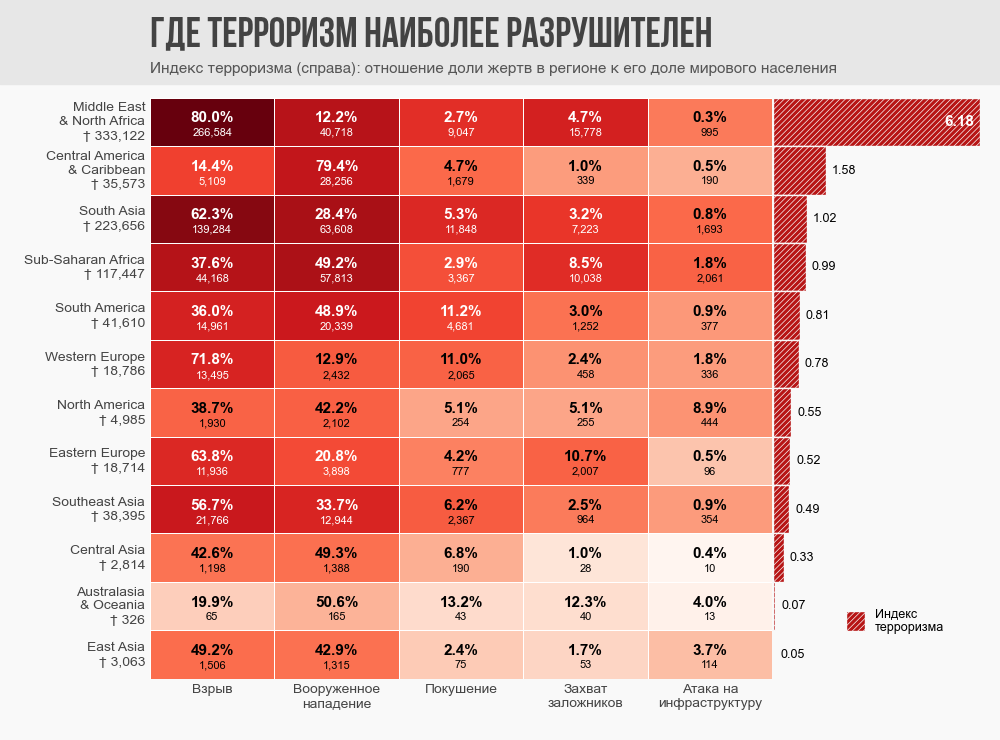

In [26]:
import numpy as np
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2,
    gridspec_kw={"width_ratios": [4.5,1.5], "wspace": 0.001}
)

plt.subplots_adjust(left=0.15, right=0.98)

# HEATMAP

hm = sb.heatmap(
    table_sorted,
    cmap="Reds",
    norm=LogNorm(
        vmin=max(table_sorted.min().min(), 1),
        vmax=table_sorted.max().max()),
    lw=0.5,
    cbar=False,
    annot=False,
    ax=axes[0]
)

mesh = hm.collections[0]
cmap = mesh.cmap
norm = mesh.norm

# текст в ячейках

for i in range(table_sorted.shape[0]):
    for j in range(table_sorted.shape[1]):

        value = table_sorted.iloc[i, j]
        pct = table_pct.iloc[i, j]

        color = cmap(norm(value))
        brightness = color[0]*0.299 + color[1]*0.587 + color[2]*0.114
        text_color = "white" if brightness < 0.5 else "black"

        axes[0].text(
            j + 0.5, i + 0.42,
            f"{pct:.1f}%",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color=text_color
        )

        axes[0].text(
            j + 0.5, i + 0.72,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=8,
            color=text_color
        )

# подписи осей

x_labels = [
    "Взрыв",
    "Вооруженное\nнападение",
    "Покушение",
    "Захват\nзаложников",
    "Атака на\nинфраструктуру"
]

axes[0].set_xticklabels(x_labels, rotation=0)

y_labels = [
    f"{region}\n† {region_totals.loc[region]:,}"
    for region in table_sorted.index
]


axes[0].set_yticklabels(
    [label.replace(" & ", "\n& ") for label in y_labels],
    rotation=0
)


axes[0].tick_params(axis="both", length=0)
axes[0].set_xlabel(" ")
axes[0].yaxis.label.set_visible(False)


# BARPLOT ИНДЕКСА

index_values = heat_index.loc[table_sorted.index, "terrorism_intensity"]

y_pos = np.arange(len(index_values))

bar_color="#B71515"

axes[1].barh(
    y_pos,
    index_values,
    color=bar_color,
    hatch="//////",
    height=1, lw=1,  edgecolor="#f9f9f9"
)

axes[1].set_ylim(len(index_values)-0.5, -0.5)
axes[1].set_xlim(0, index_values.max())

offset = index_values.max()*0.03

for i, v in enumerate(index_values):

    if v == index_values.max():
        axes[1].text(
            v - offset, i,
            f"{v:.2f}",
            va="center", ha="right",
            fontsize=11,
            color="white",
            fontweight="bold"
        )
    else:
        axes[1].text(
            v + offset, i,
            f"{v:.2f}",
            va="center",
            fontsize=9
        )

# оформление осей
axes[1].set_yticks([])
axes[1].set_xticks([])

for spine in axes[1].spines.values():
    spine.set_visible(False)


# легенда
from matplotlib.patches import Patch

legend_patch = Patch(
    facecolor=bar_color,
    hatch="//////",
    edgecolor="#f9f9f9",
    label=f"Индекс\nтерроризма",
)

axes[1].legend(
    handles=[legend_patch],
    loc="center left",
    bbox_to_anchor=(0.3, 0.1),
    frameon=False,
    handlelength=1.5,
    handleheight=2,
    fontsize=9
)

# ---------------------------

style_title(
    axes[0],
    "Где терроризм наиболее разрушителен",
    "Индекс терроризма (справа): отношение доли жертв в регионе к его доле мирового населения"
)

fig.savefig(os.path.join(path_to_save_images, f'{image_name_prefix}_image_4.png'),
                dpi=300, bbox_inches="tight")
plt.show()

#### **выводы** (4): 
Страны отсортированы по "индексу терроризма": отношение доли жертв террористичесих атак в регионе к его доле мирового населения.

Самым опасным регионом с большим отрывом является Ближний восток и Северная Африка (индекс 6.18), а самые безопасные регионы: 
- Центральная Азия (Armenia, Azerbaijan, Georgia, Kazakhstan, Kyrgyzstan, Tajikistan, Turkmenistan, Uzbekistan)
- Австралазия & Океания (Australia, Fiji, French Polynesia, New Caledonia, New Hebrides, New Zealand, Papua New Guinea и т.д.)
- и Восточная Азия (China, Hong Kong, Japan, Macau, North Korea, South Korea, Taiwan)

По абсолютному числу жертв лидируют Ближний Восток (~333 тыс) и Южная Азия (~224 тыс). В обоих регионах основной тип атак – взрывы.

В Африке к югу от Сахары, а также в Центральной и Южной Америке больше жертв приходится на вооружённые нападения, а не на взрывы.

Итого лидирующие регионы по абсолютному количеству жертв в разных типах атак:
- **взрывы**: Ближний Восток (266 тысяч жертв/ 80% от всех атак в регионе), Южная Азия (139 тысячи жертв/ 62%), Африка (44 тысячи).
- **вооруженные нападения**: Южная Азия (~64 тысячи жертв) и Африка (~58 тысячи).
- **покушение**: Южная Азия и Ближний Восток.
- **захват заложников**: Ближний Восток и Африка. 

В регионах Восточной Европы и Южной Америки общее число жертв ниже. Здесь также доминируют взрывы и вооруженные нападения.

В Северной Америке, Западной Европе, Восточной Азии (Китай, Япония, Южная и Северная Корея и т.д.) число жертв терактов относительно низкое.

В большинстве регионов именно взрывы дают наибольшее число жертв.
 

##  (5) plot  на ваш выбор

**Исторический профиль топ организаций**

In [27]:
# уберем неизвестные и безымянные группы
df_plot = df[~df["group_name"].isin(["Other", "Unknown"])].copy()

# год + месяц -> в datetime
df_plot["date"] = pd.to_datetime(
    dict(year=df_plot.year, month=df_plot.month, day=1))

# интересующие типы атак
df_plot = df_plot[df_plot["attack_type"].isin([
    "Взрыв", "Вооруженное нападение"])]

# агрегация числа атак и числа жертв
events = (df_plot
    .groupby(["group_name", "date", "attack_type"])
    .agg(events=("event_id", "count"),
         victims=("victims", "sum")).reset_index())

# активность групп за весь период
group_activity = (events.groupby("group_name")["events"]
    .sum().sort_values(ascending=False))

# список ключевых современных организаций
key_groups = [
    "Islamic State",
    "Al-Qaida",
    "Taliban",
    "Boko Haram",
    "Al-Shabaab"
]

# проверим, что ключевые группы есть в данных
key_groups = [g for g in key_groups if g in group_activity.index]

# выберем top самых активных исторически из остальных
remaining_groups = group_activity.drop(index=key_groups)
top_remaining = remaining_groups.head(5).index.tolist()

# итоговый список групп
top_groups = key_groups + top_remaining

# отфильтруем события
events = events[events["group_name"].isin(top_groups)]

# порядок групп по активности
order = (group_activity.loc[top_groups]
    .sort_values(ascending=False).index)

In [28]:
(
    events.groupby("group_name")
    .agg(
        events=("events", "sum"),
        victims=("victims", "sum"),
        explosions=("events", lambda x: x[events.loc[x.index, "attack_type"] == "Взрыв"].sum()),
        armed_attacks=("events", lambda x: x[events.loc[x.index, "attack_type"] == "Вооруженное нападение"].sum())
    )
    .sort_values("events", ascending=False)
)

,events,victims,explosions,armed_attacks
group_name,,,,
Taliban,6022,58085.0,3528,2494
Islamic State,5209,68282.0,4437,772
Shining Path,3310,12025.0,2160,1150
FMLN,3002,11660.0,1408,1594
Communist / Maoist,2472,7013.0,1460,1012
Al-Shabaab,2192,12618.0,1218,974
Boko Haram,1860,25914.0,836,1024
FARC,1670,7917.0,965,705
PKK,1634,8856.0,733,901


In [29]:
group_regions = {
    "Taliban": "Афганистан, Пакистан",
    "Islamic State": "Ирак, Сирия",
    "Shining Path": "Перу",
    "FMLN": "Сальвадор",
    "Communist / Maoist": "Индия, Непал",
    "Al-Shabaab": "Сомали, Кения",
    "Boko Haram": "Нигерия, Чад",
    "FARC": "Колумбия",
    "PKK": "Турция, Сирия, Ирак",
    "Al-Qaida": "глобальная сеть",
}

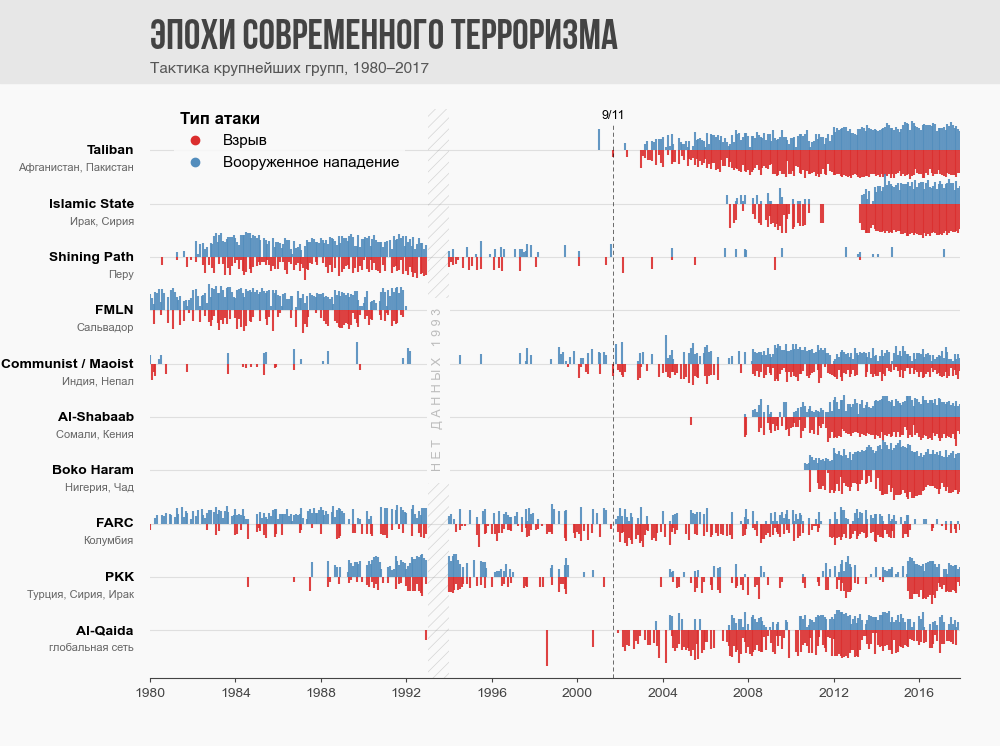

In [30]:
fig, ax = plt.subplots()
plt.subplots_adjust(left=0.15, right=0.96)

groups = list(order)
group_to_y = {g: i for i, g in enumerate(groups)}

for attack, direction, color in [
    ("Взрыв", 1, "#db2e2e"),
    ("Вооруженное нападение", -1, "#538dbd")
    ]:

    subset = events[events["attack_type"] == attack]

    y = subset["group_name"].map(group_to_y)

    ax.vlines(subset["date"],
        y, y + direction * np.log1p(subset["victims"]) * 0.08,
        color=color, alpha=0.9, lw=1.5)


# отметим 9/11
ax.axvline(pd.Timestamp("2001-09-11"), color="black", linestyle="--", 
    ymax=0.955, linewidth=0.5, alpha=0.8)
ax.text(pd.Timestamp("2001-09-11"), -0.6,
    "9/11", ha="center", fontsize=9)


# пропущены данные за 1993 в датасете
ax.axvspan(
    pd.Timestamp("1993-01-01"),
    pd.Timestamp("1993-12-31"),
    facecolor="none",
    edgecolor="grey",
    hatch="///",
    alpha=0.3, linewidth=0, ymax=0.98)

ax.text(pd.Timestamp("1993-07-01"), 4.5, "  Н Е Т   Д А Н Н Ы Х   1 9 9 3 ",
    ha="center", va="center",
    fontsize=9, rotation=90,
    color="grey", alpha=0.5,
    bbox=dict(facecolor="#f9f9f9", edgecolor="none", pad=4)
)


# добавим в подписи 'y' регион из словаря
for group in order:
    y = group_to_y[group]

    # название группы
    ax.text(-0.02, y, group,
        transform=ax.get_yaxis_transform(),
        ha="right", va="center",
        fontsize=10, fontweight="bold" )

    # регион
    region = group_regions.get(group)
    if region:
        ax.text(-0.02, y + 0.32, region,
            transform=ax.get_yaxis_transform(),
            ha="right", va="center",
            fontsize=8, color="#666666")

ax.set_yticks(range(len(order)))
ax.set_yticklabels([])

ax.set_ylim(len(groups) -0.1, -1)
ax.grid(axis="y", linestyle="-", linewidth=0.8, alpha=0.8)
ax.yaxis.label.set_visible(False)


# кастомный label
ax.set_xlabel(" \n")
legend_elements = [
    plt.scatter([], [], color="#db2e2e", label="Взрыв"),
    plt.scatter([], [], color="#538dbd", label="Вооруженное нападение")]
ax.tick_params(axis="y", length=0)



style_legend(ax, "Тип атаки", loc="tl", handles=legend_elements, shift_x=0.02)
style_title(ax,
    "Эпохи современного терроризма",
    "Тактика крупнейших групп, 1980–2017")


fig.savefig(os.path.join(path_to_save_images, f'{image_name_prefix}_image_5.png'),
                dpi=300, bbox_inches="tight")
plt.show()


#### **выводы** (5): 

В график включены 5 самых активных террористических организаций в настоящее время (Islamic State, Al-Qaida, Taliban, Boko Haram, Al-Shabaab), и 5 самых активных по числу терактов в исторической перспективе.

Коротко вспомним идейную суть организаций и географию большинства их атак:
- _Taliban_ – исламистское движение; Афганистан, Пакистан.
- _Islamic State (ISIS)_ – джихадистская; Ирак, Сирия.
- _Shining Path (Sendero Luminoso)_ – маоистское повстанческое движение; Перу.
- _FMLN (Farabundo Martí National Liberation Front)_ – леворадикальная партизанская коалиция; Сальвадор.
- _Communist / Maoist_ – маоистские и коммунистические повстанческие группы; Южная Азия (Индия, Непал) и отдельные регионы Латинской Америки.
- _Al-Shabaab_ – исламистская группировка, связанная с Al-Qaida; Сомали, Кения.
- _Boko Haram_ – джихадистская организация; Нигерия, Чад.
- _FARC_ (Revolutionary Armed Forces of Colombia) – марксистская партизанская организация; Колумбия.
- _PKK_ (Kurdistan Workers’ Party) – курдская националистическая и леворадикальная организация; Турция, Ирак, Сирия.
- _Al-Qaida_ – глобальная джихадистская террористическая сеть; Ближний Восток, Южная Азия, Северная Африка.

**График хорошо показывает смену “эпох” терроризма:**

- **В 1980–1990-е годы** наиболее активны левые революционные и партизанские движения: Shining Path, FMLN и FARC (в основном в Латинской Америке), и региональные повстанческие движения, например PKK или  маоистские группы в Южной Азии. Их основное "оружие" – вооруженные нападения. 

- **В конце 1990-х** активность многих из этих организаций снижается и наступает относительное "затишье".

- **После 2001 года** главную роль начинают играть джихадистские и исламистские организации: Al-Qaida, Taliban, а затем Islamic State, Al-Shabaab и Boko Haram.  Структура террористических актов меняется: усиливается роль взрывов, которые чаще приводят к масштабным потерям. С начала 2010-х Islamic State устраивает большое число терактов со значительным количеством жертв, и это во многом связано с активным использованием взрывов.



# Итоговый вывод по всему датасету (по всему EDA)
Анализ базы **Global Terrorism Database**

Терроризм развивается волнами и тесно связан с крупными региональными конфликтами. До начала 2000-х уровень атак и жертв выглядит очень низким по сравнению началом XXI века. Самый резкий всплеск приходится на 2012–2015 годы – период активных конфликтов на Ближнем Востоке и роста ISIS.

Самые смертоносные типы атак – взрывы и вооружeнные нападения. Именно они дают наибольшее число жертв.

Отдельные группировки ведут себя по-разному. Некоторые действуют десятилетиями и постепенно сходят на нет, другие, наоборот, резко появляются на фоне конфликтов и быстро наращивают масштаб атак (Al-Qaeda, Taliban, ISIS или Boko Haram).

В итоге из данных видно довольно простую вещь: терроризм сильнее всего растeт там, где появляются затяжные войны и политические кризисы. Именно такие конфликты создают условия для появления новых группировок и всплесков насилия.

In [31]:
print('well done!')

well done!
